# Option A — Model-relative Min-Max Normalization

This notebook reads the user-provided `soc_model_results_2.csv` and generates `option_A_model_relative_minmax_output.csv`.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

INPUT = Path("soc_model_results_2.csv")
df_raw = pd.read_csv(INPUT)

def find_col(candidates):
    lookup = {
        c.lower().replace(" ","").replace("_","").replace("-",""): c
        for c in df_raw.columns
    }
    for candidate in candidates:
        key = candidate.lower().replace(" ","").replace("_","").replace("-","")
        if key in lookup:
            return lookup[key]
    return None

def get_required(candidates, label):
    c = find_col(candidates)
    if c is None:
        raise ValueError(f"Missing required column '{label}'. Available: {list(df_raw.columns)}")
    return c

algorithm_col = get_required(["algorithm","model","regressor"], "algorithm")
r2_col = get_required(["r2"], "r2")
rmse_col = get_required(["rmse"], "rmse")
mae_col = get_required(["mae"], "mae")
pearson_col = get_required(["pearson","correlation"], "pearson")
bias_col = get_required(["bias"], "bias")

feature_col = find_col(["Feature Origin","feature_origin","featureorigin","origin"])
category_col = find_col(["category","land_use","landuse","land-use"])
soc_min_col = find_col(["soc_min","socmin"])
soc_max_col = find_col(["soc_max","socmax"])
soc_range_col = find_col(["soc_range","socrange"])
category_n_col = find_col(["category_n","sample_size","n"])
soc_mean_col = find_col(["soc_mean","socmean"])

df = pd.DataFrame({
    "algorithm": df_raw[algorithm_col],
    "Feature Origin": df_raw[feature_col] if feature_col else "",
    "r2": pd.to_numeric(df_raw[r2_col], errors="coerce"),
    "rmse": pd.to_numeric(df_raw[rmse_col], errors="coerce"),
    "mae": pd.to_numeric(df_raw[mae_col], errors="coerce"),
    "pearson": pd.to_numeric(df_raw[pearson_col], errors="coerce"),
    "bias": pd.to_numeric(df_raw[bias_col], errors="coerce"),
    "category": df_raw[category_col] if category_col else "All"
})

for name, col in [("soc_min",soc_min_col),("soc_max",soc_max_col),
                  ("soc_range",soc_range_col),("category_n",category_n_col),
                  ("soc_mean",soc_mean_col)]:
    df[name] = pd.to_numeric(df_raw[col], errors="coerce") if col else np.nan

if soc_range_col is None:
    df["soc_range"] = df["soc_max"] - df["soc_min"]

display(df.head())
print("Input columns:", list(df_raw.columns))

,algorithm,Feature Origin,r2,rmse,mae,pearson,bias,category,soc_min,soc_max,soc_range,category_n,soc_mean
0,AdaBoostRegressor,AlphaEarth,0.92,41.52,22.95,0.96,0.34,Oats,14.7,45.2,30.5,4,NaN
1,AdaBoostRegressor,AlphaEarth,0.92,41.52,22.95,0.96,0.34,Oats,14.7,45.2,30.5,4,NaN
2,GradientBoostingRegressor,AlphaEarth,0.75,54.58,20.55,0.87,-9.18,Oats,14.7,45.2,30.5,4,NaN
3,VotingRegressor,AlphaEarth,0.73,53.40,22.17,0.85,-6.64,Oats,14.7,45.2,30.5,4,NaN
4,RandomForestRegressor,AlphaEarth,0.66,54.67,21.42,0.81,-7.91,Oats,14.7,45.2,30.5,4,NaN


Input columns: ['category', 'model', 'FeatureOrigin', 'r2', 'rmse', 'mae', 'pearson', 'bias', 'soc_min', 'soc_max', 'category_n', 'soc_range', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14']


## Normalization and composite score

Higher-is-better normalization is used for $R^2$ and Pearson. Lower-is-better normalization is used for RMSE, MAE and absolute Bias.

In [25]:
def minmax_high(s):
    lo, hi = s.min(), s.max()
    if np.isclose(lo, hi):
        return pd.Series(1.0, index=s.index)
    return (s - lo) / (hi - lo)

def minmax_low(s):
    lo, hi = s.min(), s.max()
    if np.isclose(lo, hi):
        return pd.Series(1.0, index=s.index)
    return (hi - s) / (hi - lo)

df["nR2"] = df.groupby("category")["r2"].transform(minmax_high)
df["nRMSE"] = df.groupby("category")["rmse"].transform(minmax_low)
df["nMAE"] = df.groupby("category")["mae"].transform(minmax_low)
df["nBias"] = df.groupby("category")["bias"].transform(lambda s: minmax_low(s.abs()))
df["nPearson"] = df.groupby("category")["pearson"].transform(minmax_high)

df["S_R2"] = df["nR2"]
df["S_RMSE"] = df["nRMSE"]
df["S_MAE"] = df["nMAE"]
df["S_Pearson"] = df["nPearson"]
df["S_Bias"] = df["nBias"]

df["normalization_status"] = "Model-relative min-max normalized"
df["Score"] = df[["S_R2","S_RMSE","S_MAE","S_Pearson","S_Bias"]].mean(axis=1)
df["Global_Rank"] = df["Score"].rank(ascending=False, method="min").astype("Int64")
df["Category_Rank"] = df.groupby("category")["Score"].rank(
    ascending=False, method="min"
).astype("Int64")

output_cols = [
    "algorithm","Feature Origin","category","r2","rmse","mae","pearson","bias",
    "soc_min","soc_max","soc_range","category_n","soc_mean",
    "normalization_status","nRMSE","nMAE","nBias",
    "S_R2","S_RMSE","S_MAE","S_Pearson","S_Bias",
    "Score","Global_Rank","Category_Rank"
]

option_A_output = df[output_cols].copy()
option_A_output.to_csv(
    "option_A_model_relative_minmax_output.csv",
    index=False, encoding="utf-8-sig"
)
display(option_A_output.round(4))

output_cols_1 = [
    "algorithm","Feature Origin","category","r2","rmse","mae","pearson","bias",
    "soc_range","category_n", "Score"
]

option_A_output = df[output_cols_1].copy()
option_A_output.to_csv(
    "option_A_model_relative_minmax_output_art.csv",
    index=False, encoding="utf-8-sig"
)
display(option_A_output.round(4))

,algorithm,Feature Origin,category,r2,rmse,mae,pearson,bias,soc_min,soc_max,...,nMAE,nBias,S_R2,S_RMSE,S_MAE,S_Pearson,S_Bias,Score,Global_Rank,Category_Rank
0,AdaBoostRegressor,AlphaEarth,Oats,0.92,41.52,22.95,0.96,0.34,14.7,45.2,...,0.7108,0.9870,1.0000,1.0000,0.7108,1.0000,0.9870,0.9396,9,1
1,AdaBoostRegressor,AlphaEarth,Oats,0.92,41.52,22.95,0.96,0.34,14.7,45.2,...,0.7108,0.9870,1.0000,1.0000,0.7108,1.0000,0.9870,0.9396,9,1
2,GradientBoostingRegressor,AlphaEarth,Oats,0.75,54.58,20.55,0.87,-9.18,14.7,45.2,...,1.0000,0.2701,0.7069,0.3209,1.0000,0.7632,0.2701,0.6122,105,3
3,VotingRegressor,AlphaEarth,Oats,0.73,53.40,22.17,0.85,-6.64,14.7,45.2,...,0.8048,0.4761,0.6724,0.3822,0.8048,0.7105,0.4761,0.6092,108,4
4,RandomForestRegressor,AlphaEarth,Oats,0.66,54.67,21.42,0.81,-7.91,14.7,45.2,...,0.8952,0.3731,0.5517,0.3162,0.8952,0.6053,0.3731,0.5483,144,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,VotingRegressor,Sentinel + AlphaEarth,Grassland without tree/shrub cover,0.25,27.13,19.76,0.50,9.42,3.3,510.7,...,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.6000,111,2
242,GradientBoostingRegressor,AlphaEarth,Other coniferous woodland,0.25,72.12,50.39,0.50,-1.45,8.9,446.2,...,0.8846,0.8665,0.0000,0.9678,0.8846,0.0000,0.8665,0.5438,147,3
243,GradientBoostingRegressor,Sentinel + AlphaEarth,Other coniferous woodland,0.25,72.12,50.39,0.50,-1.45,8.9,446.2,...,0.8846,0.8665,0.0000,0.9678,0.8846,0.0000,0.8665,0.5438,147,3
244,ExtraTreesRegressor,Sentinel + AlphaEarth,Shrubland without tree cover,0.25,34.27,22.69,0.50,-7.19,7.5,197.0,...,0.3038,0.1407,0.0000,0.0652,0.3038,0.0000,0.1407,0.1019,236,23


,algorithm,Feature Origin,category,r2,rmse,mae,pearson,bias,soc_range,category_n,Score
0,AdaBoostRegressor,AlphaEarth,Oats,0.92,41.52,22.95,0.96,0.34,30.5,4,0.9396
1,AdaBoostRegressor,AlphaEarth,Oats,0.92,41.52,22.95,0.96,0.34,30.5,4,0.9396
2,GradientBoostingRegressor,AlphaEarth,Oats,0.75,54.58,20.55,0.87,-9.18,30.5,4,0.6122
3,VotingRegressor,AlphaEarth,Oats,0.73,53.40,22.17,0.85,-6.64,30.5,4,0.6092
4,RandomForestRegressor,AlphaEarth,Oats,0.66,54.67,21.42,0.81,-7.91,30.5,4,0.5483
...,...,...,...,...,...,...,...,...,...,...,...
241,VotingRegressor,Sentinel + AlphaEarth,Grassland without tree/shrub cover,0.25,27.13,19.76,0.50,9.42,507.4,625,0.6000
242,GradientBoostingRegressor,AlphaEarth,Other coniferous woodland,0.25,72.12,50.39,0.50,-1.45,437.3,10,0.5438
243,GradientBoostingRegressor,Sentinel + AlphaEarth,Other coniferous woodland,0.25,72.12,50.39,0.50,-1.45,437.3,10,0.5438
244,ExtraTreesRegressor,Sentinel + AlphaEarth,Shrubland without tree cover,0.25,34.27,22.69,0.50,-7.19,189.5,7,0.1019


## Ranking and visualization

ValueError: Could not interpret value `category` for `x`. An entry with this name does not appear in `data`.

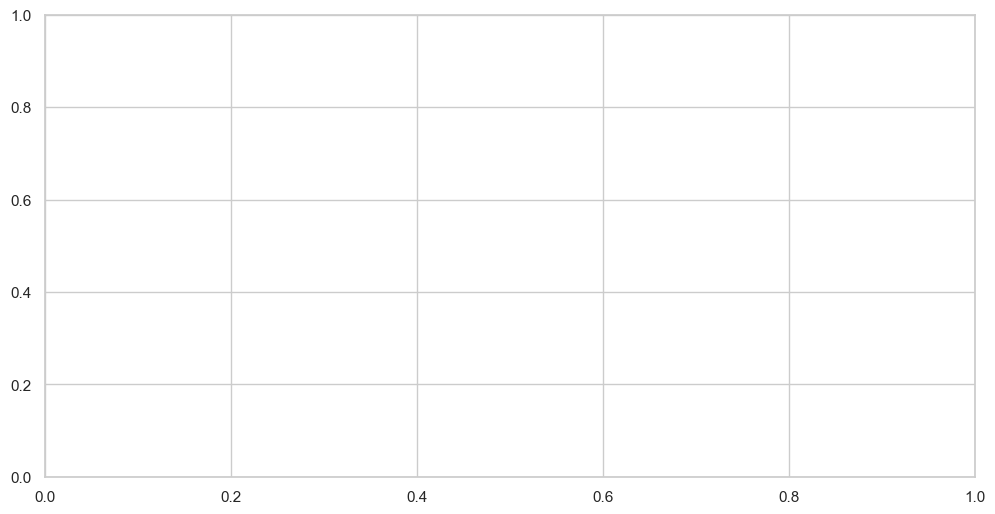

In [19]:
fig, ax = plt.subplots(figsize=(12,6))
sns.barplot(data=option_A_output, x="category", y="Score", hue="algorithm", ax=ax)
ax.set_ylim(0,1.05)
ax.set_title("Option A — Model-relative Min-Max Score")
ax.set_ylabel("Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()